# Notebook 04: Gemini AI Post Classification

**Detection Vector 4 (Weight: 15% of Manipulation Score)**

This notebook uses Google's Gemini API to perform nuanced classification of Trump's
oil-related posts. Unlike crude keyword matching, Gemini can understand context,
sarcasm, and implicit market signals.

**Why AI classification matters:**
- "Iran's soccer team played great" ≠ "bomb Iran" (keywords fail here)
- Gemini can assess fabrication risk, intent to move markets, and oscillation patterns
- Each post gets a 0-100 manipulation score with reasoning

In [18]:
import pandas as pd
import json
import time
import os
from google import genai

# Gemini API setup
GEMINI_API_KEY = 'YOUR_GEMINI_KEY_HERE'  # <-- PASTE YOUR KEY
client = genai.Client(api_key=GEMINI_API_KEY)

print('Gemini client initialized.')

Gemini client initialized.


In [19]:
# Load cleaned posts
posts = pd.read_csv('../data/processed/posts_cleaned.csv')
posts['timestamp'] = pd.to_datetime(posts['timestamp'])
posts['date'] = pd.to_datetime(posts['date'])

# Only classify posts from Feb 20, 2026 onward (Iran crisis period)
# The war started Feb 28, so Feb 20 gives us a week of pre-war baseline.
# Earlier posts are used for the master dataset (post counts, volatility baselines)
# but don't need expensive Gemini classification — the keyword classifier handles that.
crisis_posts = posts[posts['date'] >= '2026-02-20'].copy()
oil_posts = crisis_posts[crisis_posts['is_oil_related'] == True].copy().reset_index(drop=True)

print(f'Total posts in dataset: {len(posts)}')
print(f'Posts from Feb 20, 2026 onward: {len(crisis_posts)}')
print(f'Oil-related posts to classify with Gemini: {len(oil_posts)}')
print(f'Estimated Gemini time: ~{len(oil_posts) * 4 / 60:.0f} minutes')

Total posts in dataset: 21014
Posts from Feb 20, 2026 onward: 628
Oil-related posts to classify with Gemini: 194
Estimated Gemini time: ~13 minutes


In [22]:
def classify_post_gemini(post_text, previous_text=None):
    """
    Use Gemini to classify a Trump Truth Social post for market manipulation indicators.
    
    Returns dict with scores and reasoning.
    """
    prev_context = f'\nPREVIOUS POST (within 48h): "{previous_text}"' if previous_text else ''
    
    prompt = f"""Analyze this Trump Truth Social post for oil market manipulation indicators.

POST TEXT: "{post_text}"
{prev_context}

Score each dimension 0-100:

1. DIRECTION_INTENT: Does this signal oil prices UP or DOWN?
   0 = Maximum escalation (war threats, bombing, destruction → oil UP)
   100 = Maximum de-escalation (peace, talks, deals → oil DOWN)

2. VERIFIABILITY: Can the factual claims be independently verified?
   0 = Pure opinion/emotion
   100 = Specific verifiable facts

3. FABRICATION_RISK: How likely is this claim to be false or fabricated?
   0 = Certainly true
   100 = Certainly false

4. OSCILLATION_RISK: Does this contradict the previous post?
   0 = Consistent position
   100 = Complete reversal

5. MARKET_IMPACT_INTENT: Was this post designed to move markets?
   Consider: timing, ALL CAPS, exclamation marks, vague claims, threats
   0 = No market intent
   100 = Clear intent to influence prices

6. CATEGORY: One of ESCALATION, DE_ESCALATION, NEUTRAL, FABRICATION

Return ONLY valid JSON:
{{
    "direction_intent": <0-100>,
    "verifiability": <0-100>,
    "fabrication_risk": <0-100>,
    "oscillation_risk": <0-100>,
    "market_impact_intent": <0-100>,
    "category": "<ESCALATION|DE_ESCALATION|NEUTRAL|FABRICATION>",
    "reasoning": "<one sentence explanation>"
}}"""
    
    try:
        response = client.models.generate_content(
            model='gemini-3.1-flash-lite-preview',
            contents=prompt
        )
        
        # Parse JSON from response
        text = response.text.strip()
        # Remove markdown code fences if present
        if text.startswith('```'):
            text = text.split('\n', 1)[1]
            text = text.rsplit('```', 1)[0]
        
        return json.loads(text)
    
    except json.JSONDecodeError as e:
        print(f'  JSON parse error: {e}')
        print(f'  Raw response: {response.text[:200]}')
        return None
    except Exception as e:
        print(f'  API error: {e}')
        return None

In [23]:
# Test with one post first
if GEMINI_API_KEY != 'YOUR_GEMINI_KEY_HERE':
    test_result = classify_post_gemini(oil_posts.iloc[0]['post_text'])
    print('Test classification:')
    print(json.dumps(test_result, indent=2))
else:
    print('Set your Gemini API key above to test.')

Test classification:
{
  "direction_intent": 20,
  "verifiability": 60,
  "fabrication_risk": 30,
  "oscillation_risk": 20,
  "market_impact_intent": 85,
  "category": "ESCALATION",
  "reasoning": "The post signals a protectionist trade war through the implementation of broad tariffs, which typically exerts upward pressure on energy costs by disrupting global supply chains and increasing input prices."
}


In [24]:
import asyncio
import concurrent.futures

MAX_WORKERS = 10  # 10 concurrent Gemini requests

def _build_result(row, idx, classification):
    """Build result dict from a classification (or fallback)."""
    if classification:
        return {
            'post_id': row.get('post_id', idx),
            'date': str(row['date']),
            'timestamp': str(row['timestamp']),
            'post_text': row['post_text'][:200],
            'direction_intent': classification.get('direction_intent', 50),
            'verifiability': classification.get('verifiability', 50),
            'fabrication_risk': classification.get('fabrication_risk', 0),
            'oscillation_risk': classification.get('oscillation_risk', 0),
            'market_impact_intent': classification.get('market_impact_intent', 0),
            'category': classification.get('category', 'NEUTRAL'),
            'reasoning': classification.get('reasoning', ''),
        }
    else:
        return {
            'post_id': row.get('post_id', idx),
            'date': str(row['date']),
            'timestamp': str(row['timestamp']),
            'post_text': row['post_text'][:200],
            'direction_intent': 50,
            'verifiability': 50,
            'fabrication_risk': 0,
            'oscillation_risk': 0,
            'market_impact_intent': 0,
            'category': row.get('direction_keyword', 'NEUTRAL').upper(),
            'reasoning': 'API call failed, using keyword fallback',
        }

def _classify_one(args):
    """Classify a single post (runs in thread pool)."""
    idx, row, prev_text = args
    classification = classify_post_gemini(row['post_text'], prev_text)
    return idx, _build_result(row, idx, classification)

def classify_all_posts_concurrent(posts_df, max_workers=MAX_WORKERS,
                                  checkpoint_path='../data/processed/gemini_partial.csv',
                                  checkpoint_every=50):
    """
    Classify posts using a thread pool for concurrent Gemini API calls.
    Resumes from checkpoint if available.
    """
    results = {}
    start_idx = 0

    # Resume from checkpoint
    if os.path.exists(checkpoint_path):
        existing = pd.read_csv(checkpoint_path)
        for i, rec in existing.iterrows():
            results[i] = rec.to_dict()
        start_idx = len(results)
        print(f'Resuming from checkpoint at index {start_idx}')

    # Build work items (with previous-post context for oscillation scoring)
    work = []
    for i in range(start_idx, len(posts_df)):
        row = posts_df.iloc[i]
        prev_text = None
        if i > 0:
            prev_row = posts_df.iloc[i - 1]
            time_diff = (row['timestamp'] - prev_row['timestamp']).total_seconds() / 3600
            if time_diff <= 48:
                prev_text = prev_row['post_text']
        work.append((i, row, prev_text))

    total = len(posts_df)
    print(f'Classifying {len(work)} posts with {max_workers} concurrent workers...')

    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_classify_one, w): w[0] for w in work}
        done_count = start_idx
        for future in concurrent.futures.as_completed(futures):
            idx, result = future.result()
            results[idx] = result
            done_count += 1

            if done_count % checkpoint_every == 0:
                # Save checkpoint (sorted by index)
                sorted_results = [results[k] for k in sorted(results.keys())]
                pd.DataFrame(sorted_results).to_csv(checkpoint_path, index=False)
                print(f'  Checkpoint: {done_count}/{total} classified')

    # Final sorted output
    sorted_results = [results[k] for k in sorted(results.keys())]
    return pd.DataFrame(sorted_results)

# Run classification
print(f'Posts to classify: {len(oil_posts)}')
print(f'Estimated time: ~{len(oil_posts) / MAX_WORKERS * 1.5 / 60:.1f} minutes '
      f'({MAX_WORKERS} concurrent requests)\n')

gemini_results = classify_all_posts_concurrent(oil_posts)
gemini_results.to_csv('../data/processed/gemini_classifications.csv', index=False)
print(f'\nDone! Saved {len(gemini_results)} classifications.')

Posts to classify: 194
Estimated time: ~0.5 minutes (10 concurrent requests)

Resuming from checkpoint at index 100
Classifying 94 posts with 10 concurrent workers...


  Checkpoint: 150/194 classified



Done! Saved 194 classifications.


In [25]:
# Analysis of classification results
gemini_df = pd.read_csv('../data/processed/gemini_classifications.csv')

print('=== GEMINI CLASSIFICATION SUMMARY ===')
print(f'\nCategory distribution:')
print(gemini_df['category'].value_counts())

print(f'\nAverage scores:')
for col in ['direction_intent', 'verifiability', 'fabrication_risk', 
            'oscillation_risk', 'market_impact_intent']:
    if col in gemini_df.columns:
        print(f'  {col}: {gemini_df[col].mean():.1f}')

# Show highest manipulation intent posts
if 'market_impact_intent' in gemini_df.columns:
    print(f'\nTop 10 highest market impact intent:')
    top = gemini_df.nlargest(10, 'market_impact_intent')
    for _, row in top.iterrows():
        print(f'  [{row["date"]}] Score: {row["market_impact_intent"]} | {row["category"]} | {str(row["post_text"])[:80]}...')

=== GEMINI CLASSIFICATION SUMMARY ===

Category distribution:
category
NEUTRAL          110
ESCALATION        65
DE_ESCALATION     11
FABRICATION        8
Name: count, dtype: int64

Average scores:
  direction_intent: 38.7
  verifiability: 39.2
  fabrication_risk: 52.9
  oscillation_risk: 13.6
  market_impact_intent: 38.7

Top 10 highest market impact intent:
  [2026-03-10 00:00:00] Score: 95 | FABRICATION | America is returning to REAL ENERGY DOMINANCE! Today I am proud to announce that...
  [2026-03-13 00:00:00] Score: 95 | ESCALATION | Moments ago, at my direction, the United States Central Command executed one of ...
  [2026-03-18 00:00:00] Score: 95 | ESCALATION | Israel, out of anger for what has taken place in the Middle East, has violently ...
  [2026-03-18 00:00:00] Score: 95 | FABRICATION | Graham tears into European allies over Strait of Hormuz reluctance:https://thehi...
  [2026-03-21 00:00:00] Score: 95 | ESCALATION | If Iran doesn’t FULLY OPEN, WITHOUT THREAT, the Strait 

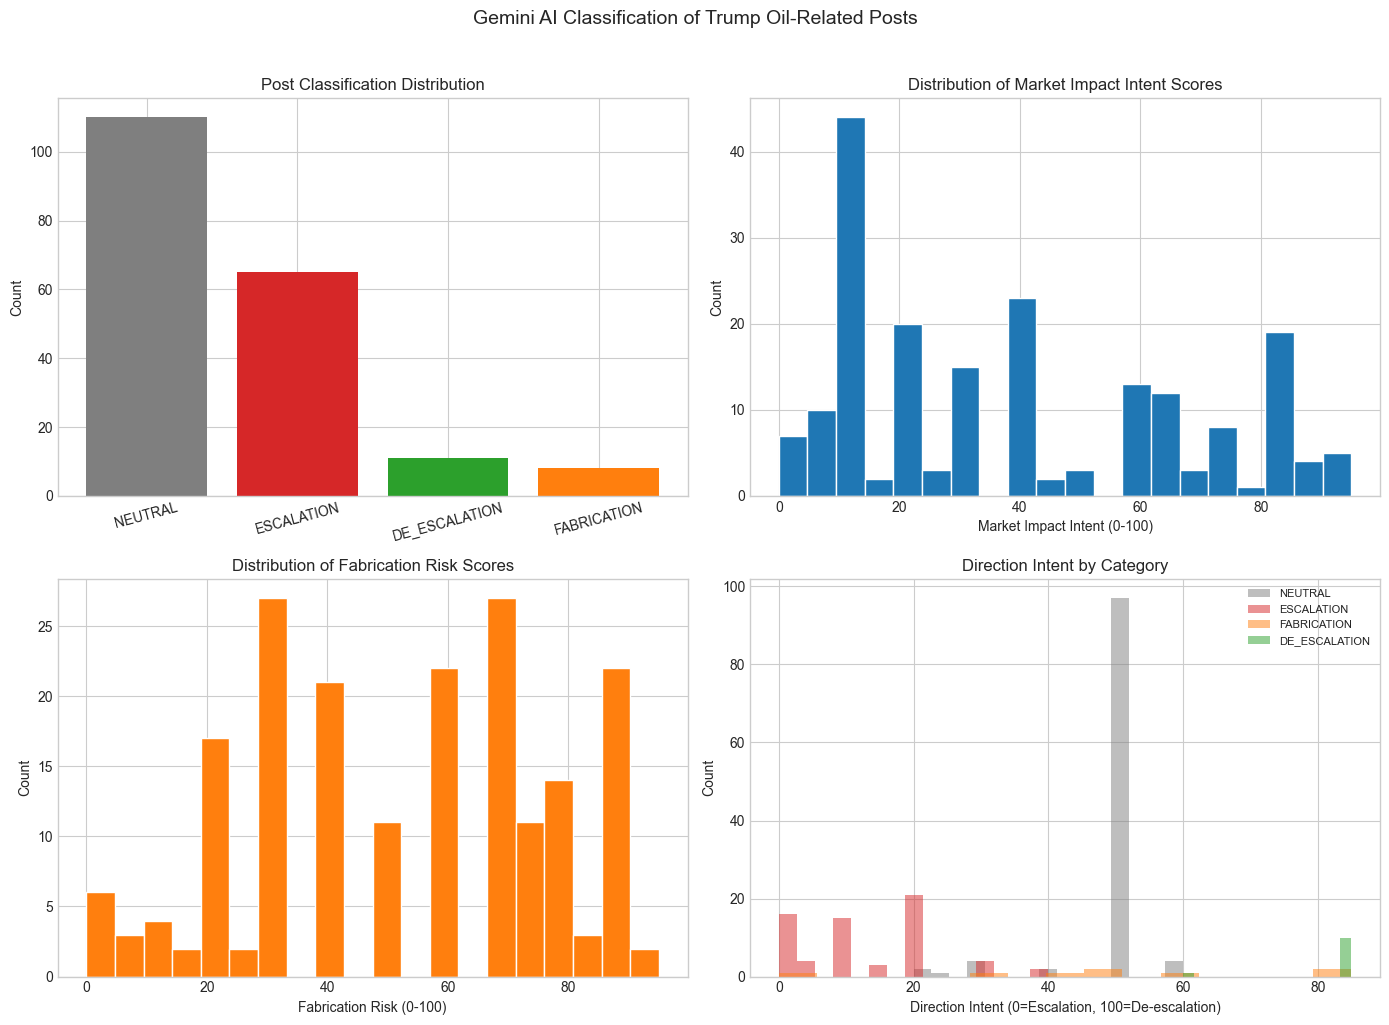


Next step: Run notebook 05 for fabrication and causality analysis.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Category distribution
cat_counts = gemini_df['category'].value_counts()
colors = [{'ESCALATION': '#d62728', 'DE_ESCALATION': '#2ca02c', 
           'NEUTRAL': '#7f7f7f', 'FABRICATION': '#ff7f0e'}.get(c, '#999')
          for c in cat_counts.index]
axes[0, 0].bar(cat_counts.index, cat_counts.values, color=colors)
axes[0, 0].set_title('Post Classification Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=15)

# Market impact intent histogram
if 'market_impact_intent' in gemini_df.columns:
    axes[0, 1].hist(gemini_df['market_impact_intent'], bins=20, color='#1f77b4', edgecolor='white')
    axes[0, 1].set_title('Distribution of Market Impact Intent Scores')
    axes[0, 1].set_xlabel('Market Impact Intent (0-100)')
    axes[0, 1].set_ylabel('Count')

# Fabrication risk histogram
if 'fabrication_risk' in gemini_df.columns:
    axes[1, 0].hist(gemini_df['fabrication_risk'], bins=20, color='#ff7f0e', edgecolor='white')
    axes[1, 0].set_title('Distribution of Fabrication Risk Scores')
    axes[1, 0].set_xlabel('Fabrication Risk (0-100)')
    axes[1, 0].set_ylabel('Count')

# Direction intent by category
if 'direction_intent' in gemini_df.columns:
    for cat in gemini_df['category'].unique():
        subset = gemini_df[gemini_df['category'] == cat]
        color = {'ESCALATION': '#d62728', 'DE_ESCALATION': '#2ca02c', 
                 'NEUTRAL': '#7f7f7f', 'FABRICATION': '#ff7f0e'}.get(cat, '#999')
        axes[1, 1].hist(subset['direction_intent'], bins=15, alpha=0.5, 
                        label=cat, color=color)
    axes[1, 1].set_title('Direction Intent by Category')
    axes[1, 1].set_xlabel('Direction Intent (0=Escalation, 100=De-escalation)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend(fontsize=8)

plt.suptitle('Gemini AI Classification of Trump Oil-Related Posts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_gemini_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNext step: Run notebook 05 for fabrication and causality analysis.')